Dataset Shape: (598, 13)

First 5 rows:
    Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No         0.0      Graduate            No   
1  LP001003   Male     Yes         1.0      Graduate            No   
2  LP001005   Male     Yes         0.0      Graduate           Yes   
3  LP001006   Male     Yes         0.0  Not Graduate            No   
4  LP001008   Male      No         0.0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0   

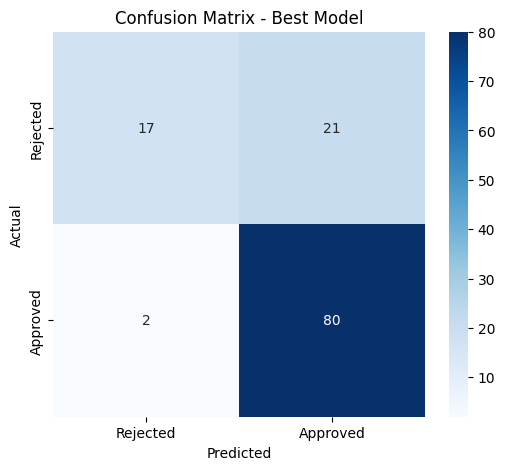


FINAL BEST MODEL RESULTS
Model: Tuned Random Forest
Accuracy : 80.83 %
Precision: 79.21 %
Recall   : 97.56 %
F1 Score : 87.43 %
ROC-AUC  : 85.33 %


In [ ]:
# LOAN APPROVAL PREDICTION 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("LoanApprovalPrediction.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 2. BASIC CLEANING
# ============================================================

# Remove Loan_ID because it does not help prediction
if "Loan_ID" in df.columns:
    df = df.drop("Loan_ID", axis=1)

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape after cleaning:", df.shape)


# ============================================================
# 3. TARGET COLUMN
# ============================================================

target = "Loan_Status"

# Convert target to 0 and 1
df[target] = df[target].map({
    "Y": 1,
    "N": 0
})

# Remove rows where target is missing
df = df.dropna(subset=[target])

X = df.drop(target, axis=1)
y = df[target]

print("\nTarget Distribution:")
print(y.value_counts())


# ============================================================
# 4. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 5. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# ============================================================
# 6. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 7. RANDOM FOREST WITH HYPERPARAMETER TUNING
# ============================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")

rf_search.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(rf_search.best_score_, 4))


# ============================================================
# 8. GRADIENT BOOSTING
# ============================================================

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_params = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    gb_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Gradient Boosting...")

gb_search.fit(X_train, y_train)

print("\nBest Gradient Boosting Parameters:")
print(gb_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(gb_search.best_score_, 4))


# ============================================================
# 9. LOGISTIC REGRESSION
# ============================================================

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

print("\nTraining Logistic Regression...")

lr_pipeline.fit(X_train, y_train)


# ============================================================
# 10. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, model):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Rejected", "Approved"],
        zero_division=0
    ))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


# ============================================================
# 11. EVALUATE ALL MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        "Tuned Random Forest",
        rf_search.best_estimator_
    )
)

results.append(
    evaluate_model(
        "Tuned Gradient Boosting",
        gb_search.best_estimator_
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        lr_pipeline
    )
)


# ============================================================
# 12. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
print("=" * 80)

print(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).round(4)
)


# ============================================================
# 13. CONFUSION MATRIX FOR BEST MODEL
# ============================================================

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("\nBest Model based on F1 Score:")
print(best_model_name)


if best_model_name == "Tuned Random Forest":
    best_model = rf_search.best_estimator_

elif best_model_name == "Tuned Gradient Boosting":
    best_model = gb_search.best_estimator_

else:
    best_model = lr_pipeline


y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Model")
plt.show()


# ============================================================
# 14. FINAL RESULT
# ============================================================

best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("\nFINAL BEST MODEL RESULTS")
print("=" * 50)

print("Model:", best_model_name)
print("Accuracy :", round(best_result["Accuracy"] * 100, 2), "%")
print("Precision:", round(best_result["Precision"] * 100, 2), "%")
print("Recall   :", round(best_result["Recall"] * 100, 2), "%")
print("F1 Score :", round(best_result["F1 Score"] * 100, 2), "%")
print("ROC-AUC  :", round(best_result["ROC-AUC"] * 100, 2), "%")